<a href="https://colab.research.google.com/github/Rancor06/Salman-Inten-Projects/blob/main/Phase%202/Day%2013/Day_13_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

# Upload file from local drive
uploaded = files.upload()
# Load dataset
df = pd.read_csv('student_performance.csv')
df.head()

Saving student_performance.csv to student_performance.csv


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [6]:
# Select Features and Target Variable
X = df[['weekly_self_study_hours']]
Y = df['total_score']

# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print("Training Sample:\n",X_train.head())
print("Testing Sample:\n",X_test.head())

Training Sample:
         weekly_self_study_hours
566853                     23.0
382311                     16.9
241519                     10.8
719220                     13.2
905718                     14.0
Testing Sample:
         weekly_self_study_hours
987231                      3.9
79954                      17.1
567130                      8.7
500891                     15.0
55399                       0.9
Training Sample:
         weekly_self_study_hours
566853                     23.0
382311                     16.9
241519                     10.8
719220                     13.2
905718                     14.0
Testing Sample:
         weekly_self_study_hours
987231                      3.9
79954                      17.1
567130                      8.7
500891                     15.0
55399                       0.9


In [7]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the values
y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


In [8]:
# TASK 1: Actual vs Predicted Values
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
comparison_df['Difference'] = comparison_df['Actual'] - comparison_df['Predicted']

print(comparison_df.head(10)) # Has 1M rows so will take only first 10

   Actual  Predicted  Difference
0    53.9  64.056714  -10.156714
1    77.3  88.038713  -10.738713
2    75.0  72.777441    2.222559
3    85.7  84.223395    1.476605
4    30.8  58.606259  -27.806259
5    62.3  63.875032   -1.575032
6    74.0  64.420077    9.579923
7    68.9  64.601759    4.298241
8    83.7  85.131804   -1.431804
9    95.5  79.681350   15.818650


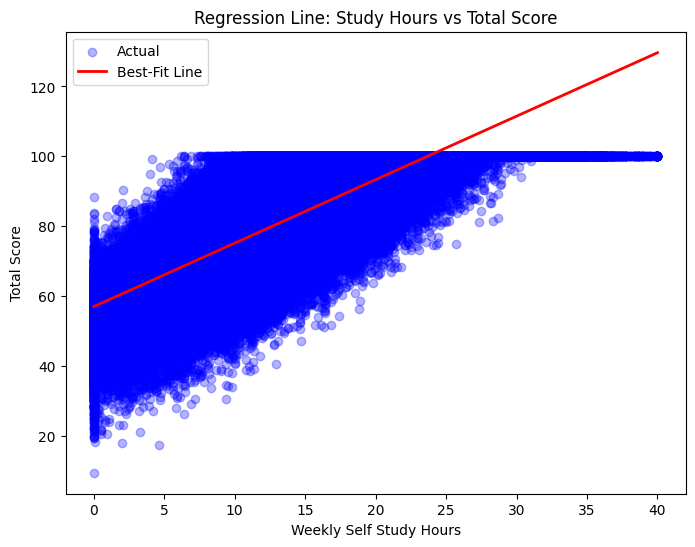

In [9]:
# TASK 2: Regression Line Plot
plt.figure(figsize=(8,6))
plt.scatter(X_test['weekly_self_study_hours'], y_test, color='blue', alpha=0.3, label='Actual')

# Sort for a clean line
sorted_idx = X_test['weekly_self_study_hours'].argsort()
plt.plot(X_test['weekly_self_study_hours'].values[sorted_idx],
         y_pred[sorted_idx], color='red', linewidth=2, label='Best-Fit Line')

plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.title('Regression Line: Study Hours vs Total Score')
plt.legend()
plt.show()

In [10]:
# TASK 3: Slope, Intercept, and Equation
m = model.coef_[0]
c = model.intercept_

print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")
print(f"Equation: y = {m:.4f}x + {c:.4f}")

Slope (m): 1.8168
Intercept (c): 56.9711
Equation: y = 1.8168x + 56.9711


In [11]:
# TASK 4: MAE, MSE, R2 Score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE (Mean Absolute Error): 7.1613
MSE (Mean Squared Error): 80.9350
R² Score: 0.6600


In [12]:
# TASK 5: Predict 3 New Values
new_data = pd.DataFrame({
    'weekly_self_study_hours': [5, 15, 25]
})

new_predictions = model.predict(new_data)

for hours, pred in zip(new_data['weekly_self_study_hours'], new_predictions):
    print(f"Study Hours: {hours} -> Predicted Total Score: {pred:.2f}")

Study Hours: 5 -> Predicted Total Score: 66.06
Study Hours: 15 -> Predicted Total Score: 84.22
Study Hours: 25 -> Predicted Total Score: 102.39


In [13]:
# TASK 6: Model Performance Verdict
print("Model Performance Summary")
print('-' * 30)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

if r2 >= 0.85:
    verdict = "Best"
    reason = "The model explains most of the variance in total_score, and prediction errors are low."
elif r2 >= 0.60:
    verdict = "Good"
    reason = "The model captures a solid portion of the relationship, though some variance remains unexplained."
else:
    verdict = "Needs Improvement"
    reason = "The model explains only a limited portion of the variance; predictions may be unreliable."

print(f"\nVerdict: {verdict}")
print(f"Reason: {reason}")

Model Performance Summary
------------------------------
MAE: 7.1613
MSE: 80.9350
R² Score: 0.6600

Verdict: Good
Reason: The model captures a solid portion of the relationship, though some variance remains unexplained.
